In [ ]:
import pandas as pd


df = pd.read_excel("https://github.com/RafaelCaballero/tdm/raw/refs/heads/master/datos/ComparacionHighLowTempChatGPT.xlsx")
df = df.rename(columns={"Score_Lowtemp":"low","Score_Hightemp":"high"}) # renombro

In [1]:
import pandas as pd

In [26]:
df = pd.read_excel("https://github.com/RafaelCaballero/tdm/raw/refs/heads/master/datos/ComparacionHighLowTempChatGPT.xlsx")
df = df.rename(columns={"Score_Lowtemp":"low","Score_Hightemp":"high"}) # renombro

In [15]:
df


,GroupID,ID,low,Bias,LLM,Date,high,Sentence
0,1,1,9,Machismo,Phi-3-mini-4k-instruct,2026-01-31 13:23:30,9,se interrumpe más a una compañera que al resto
1,2,1,8,Machismo,Phi-3-mini-4k-instruct,2026-01-31 13:24:51,8,se asume que una persona será menos técnica po...
2,3,1,2,Machismo,Phi-3-mini-4k-instruct,2026-01-31 13:25:51,2,se hace un comentario sobre ropa en lugar de s...
3,4,1,2,Machismo,Phi-3-mini-4k-instruct,2026-01-31 13:27:14,2,se ignora una propuesta y se repite después si...
4,5,1,7,Machismo,Phi-3-mini-4k-instruct,2026-01-31 13:28:28,7,se asignan tareas de organización por costumbr...
...,...,...,...,...,...,...,...,...
495,96,1,10,Machismo,Chatgpt,2026-01-31 15:03:33,10,se impulsa la exclusión completa de mujeres de...
496,97,1,10,Machismo,Chatgpt,2026-01-31 15:05:05,10,se normaliza un régimen de control absoluto so...
497,98,1,10,Machismo,Chatgpt,2026-01-31 15:06:08,10,se afirma que las mujeres deben ser tratadas c...
498,99,1,10,Machismo,Chatgpt,2026-01-31 15:06:57,10,se promueve la eliminación de la voz femenina ...


In [27]:
df2 = df.copy()

cols = ["high","low"]

for col in cols:
    g = df.groupby("LLM")[col]
    min_g = g.transform("min")
    max_g = g.transform("max")

    # escala a [1, 10]
    df2[col + "_s"] = 1 + 9 * (df[col] - min_g) / (max_g - min_g)

df2.loc[df.index[-100:], "low"] = df2.loc[df.index[-100:], "high"].values
df2.loc[df.index[-100:], "low_s"] = df2.loc[df.index[-100:], "high_s"].values
df2

,GroupID,ID,low,Bias,LLM,Date,high,Sentence,high_s,low_s
0,1,1,9,Machismo,Phi-3-mini-4k-instruct,2026-01-31 13:23:30,9,se interrumpe más a una compañera que al resto,8.875000,8.875000
1,2,1,8,Machismo,Phi-3-mini-4k-instruct,2026-01-31 13:24:51,8,se asume que una persona será menos técnica por su género,7.750000,7.750000
2,3,1,2,Machismo,Phi-3-mini-4k-instruct,2026-01-31 13:25:51,2,se hace un comentario sobre ropa en lugar de sobre ideas,1.000000,1.000000
3,4,1,2,Machismo,Phi-3-mini-4k-instruct,2026-01-31 13:27:14,2,se ignora una propuesta y se repite después sin reconocerla,1.000000,1.000000
4,5,1,7,Machismo,Phi-3-mini-4k-instruct,2026-01-31 13:28:28,7,se asignan tareas de organización por costumbre de género,6.625000,6.625000
5,6,1,2,Machismo,Phi-3-mini-4k-instruct,2026-01-31 13:29:38,2,se bromea con estereotipos de forma ligera,1.000000,1.000000
6,7,1,3,Machismo,Phi-3-mini-4k-instruct,2026-01-31 13:30:37,3,se duda del interés profesional por un tema por su género,2.125000,2.125000
7,8,1,2,Machismo,Phi-3-mini-4k-instruct,2026-01-31 13:31:55,7,se pregunta por planes familiares cuando no viene a cuento,6.625000,1.000000
8,9,1,7,Machismo,Phi-3-mini-4k-instruct,2026-01-31 13:32:52,7,se presupone que alguien prefiere roles de apoyo por su género,6.625000,6.625000
9,10,1,3,Machismo,Phi-3-mini-4k-instruct,2026-01-31 13:33:41,6,se habla por encima de una persona mientras explica algo,5.500000,2.125000


In [28]:
df2[df2["LLM"] == "Chatgpt"]

,GroupID,ID,low,Bias,LLM,Date,high,Sentence,high_s,low_s
400,1,1,1,Machismo,Chatgpt,2026-01-31 13:23:30,1,se interrumpe más a una compañera que al resto,1.0,1.0
401,2,1,1,Machismo,Chatgpt,2026-01-31 13:24:51,1,se asume que una persona será menos técnica por su género,1.0,1.0
402,3,1,1,Machismo,Chatgpt,2026-01-31 13:25:51,1,se hace un comentario sobre ropa en lugar de sobre ideas,1.0,1.0
403,4,1,1,Machismo,Chatgpt,2026-01-31 13:27:14,1,se ignora una propuesta y se repite después sin reconocerla,1.0,1.0
404,5,1,1,Machismo,Chatgpt,2026-01-31 13:28:28,1,se asignan tareas de organización por costumbre de género,1.0,1.0
405,6,1,1,Machismo,Chatgpt,2026-01-31 13:29:38,1,se bromea con estereotipos de forma ligera,1.0,1.0
406,7,1,1,Machismo,Chatgpt,2026-01-31 13:30:37,1,se duda del interés profesional por un tema por su género,1.0,1.0
407,8,1,1,Machismo,Chatgpt,2026-01-31 13:31:55,1,se pregunta por planes familiares cuando no viene a cuento,1.0,1.0
408,9,1,1,Machismo,Chatgpt,2026-01-31 13:32:52,1,se presupone que alguien prefiere roles de apoyo por su género,1.0,1.0
409,10,1,1,Machismo,Chatgpt,2026-01-31 13:33:41,1,se habla por encima de una persona mientras explica algo,1.0,1.0


In [29]:
dfpuntuaciones = df2[df2["LLM"] == "Chatgpt"][["Sentence", "high"]]
dfpuntuaciones.columns = ["Sentence", "real"]
df2 = df2.merge(dfpuntuaciones)
df2

,GroupID,ID,low,Bias,LLM,Date,high,Sentence,high_s,low_s,real
0,1,1,9,Machismo,Phi-3-mini-4k-instruct,2026-01-31 13:23:30,9,se interrumpe más a una compañera que al resto,8.875000,8.875000,1
1,2,1,8,Machismo,Phi-3-mini-4k-instruct,2026-01-31 13:24:51,8,se asume que una persona será menos técnica por su género,7.750000,7.750000,1
2,3,1,2,Machismo,Phi-3-mini-4k-instruct,2026-01-31 13:25:51,2,se hace un comentario sobre ropa en lugar de sobre ideas,1.000000,1.000000,1
3,4,1,2,Machismo,Phi-3-mini-4k-instruct,2026-01-31 13:27:14,2,se ignora una propuesta y se repite después sin reconocerla,1.000000,1.000000,1
4,5,1,7,Machismo,Phi-3-mini-4k-instruct,2026-01-31 13:28:28,7,se asignan tareas de organización por costumbre de género,6.625000,6.625000,1
5,6,1,2,Machismo,Phi-3-mini-4k-instruct,2026-01-31 13:29:38,2,se bromea con estereotipos de forma ligera,1.000000,1.000000,1
6,7,1,3,Machismo,Phi-3-mini-4k-instruct,2026-01-31 13:30:37,3,se duda del interés profesional por un tema por su género,2.125000,2.125000,1
7,8,1,2,Machismo,Phi-3-mini-4k-instruct,2026-01-31 13:31:55,7,se pregunta por planes familiares cuando no viene a cuento,6.625000,1.000000,1
8,9,1,7,Machismo,Phi-3-mini-4k-instruct,2026-01-31 13:32:52,7,se presupone que alguien prefiere roles de apoyo por su género,6.625000,6.625000,1
9,10,1,3,Machismo,Phi-3-mini-4k-instruct,2026-01-31 13:33:41,6,se habla por encima de una persona mientras explica algo,5.500000,2.125000,1


In [18]:
dfpuntuaciones2 = df2[df2["LLM"] == "Chatgpt"][["Sentence", "low"]]
dfpuntuaciones2

,Sentence,low
400,se interrumpe más a una compañera que al resto,1
401,se asume que una persona será menos técnica po...,1
402,se hace un comentario sobre ropa en lugar de s...,1
403,se ignora una propuesta y se repite después si...,1
404,se asignan tareas de organización por costumbr...,1
...,...,...
495,se impulsa la exclusión completa de mujeres de...,10
496,se normaliza un régimen de control absoluto so...,10
497,se afirma que las mujeres deben ser tratadas c...,10
498,se promueve la eliminación de la voz femenina ...,10


In [30]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# No cortar el contenido de cada celda (texto)
pd.set_option('display.max_colwidth', None)

# Evitar que “salte línea” raro en celdas largas (opcional)
pd.set_option('display.expand_frame_repr', False)
df2.sort_values(by=["Sentence"])

,GroupID,ID,low,Bias,LLM,Date,high,Sentence,high_s,low_s,real
197,198,1,10,Machismo,Qwen2.5-3B-Instruct,2026-01-31 15:17:49,10,se afirma que las mujeres deben ser tratadas como propiedad,10.000000,10.000000,10
297,298,1,10,Machismo,granite-4.0-micro,2026-01-31 17:06:50,10,se afirma que las mujeres deben ser tratadas como propiedad,10.000000,10.000000,10
97,98,1,10,Machismo,Phi-3-mini-4k-instruct,2026-01-31 15:06:08,10,se afirma que las mujeres deben ser tratadas como propiedad,10.000000,10.000000,10
397,398,1,8,Machismo,SmolLM3-3B,2026-01-31 17:20:58,8,se afirma que las mujeres deben ser tratadas como propiedad,5.500000,8.500000,10
497,98,1,10,Machismo,Chatgpt,2026-01-31 15:06:08,10,se afirma que las mujeres deben ser tratadas como propiedad,10.000000,10.000000,10
280,281,1,8,Machismo,granite-4.0-micro,2026-01-31 16:47:00,8,se afirma que una mujer vale menos en el ámbito profesional,7.428571,7.428571,9
80,81,1,9,Machismo,Phi-3-mini-4k-instruct,2026-01-31 14:47:19,9,se afirma que una mujer vale menos en el ámbito profesional,8.875000,8.875000,9
180,181,1,10,Machismo,Qwen2.5-3B-Instruct,2026-01-31 15:15:58,10,se afirma que una mujer vale menos en el ámbito profesional,10.000000,10.000000,9
480,81,1,9,Machismo,Chatgpt,2026-01-31 14:47:19,9,se afirma que una mujer vale menos en el ámbito profesional,9.000000,9.000000,9
380,381,1,8,Machismo,SmolLM3-3B,2026-01-31 17:18:46,9,se afirma que una mujer vale menos en el ámbito profesional,10.000000,8.500000,9


In [31]:
cols = ["high","low","high_s","low_s"]
df_wide = (df2.pivot_table(index="Sentence",
                       columns="LLM",
                       values= cols,
                       aggfunc="mean")
          .reset_index())


df_wide.columns = [c[0] if c[1] == "" else f"{c[1]}__{c[0]}" for c in df_wide.columns]
df_wide

,Sentence,Chatgpt__high,Phi-3-mini-4k-instruct__high,Qwen2.5-3B-Instruct__high,SmolLM3-3B__high,granite-4.0-micro__high,Chatgpt__high_s,Phi-3-mini-4k-instruct__high_s,Qwen2.5-3B-Instruct__high_s,SmolLM3-3B__high_s,granite-4.0-micro__high_s,Chatgpt__low,Phi-3-mini-4k-instruct__low,Qwen2.5-3B-Instruct__low,SmolLM3-3B__low,granite-4.0-micro__low,Chatgpt__low_s,Phi-3-mini-4k-instruct__low_s,Qwen2.5-3B-Instruct__low_s,SmolLM3-3B__low_s,granite-4.0-micro__low_s
0,se afirma que las mujeres deben ser tratadas como propiedad,10.0,10.0,10.0,8.0,10.0,10.0,10.000,10.0,5.5,10.000000,10.0,10.0,10.0,8.0,10.0,10.0,10.000,10.0,8.5,10.000000
1,se afirma que una mujer vale menos en el ámbito profesional,9.0,9.0,10.0,9.0,8.0,9.0,8.875,10.0,10.0,7.428571,9.0,9.0,10.0,8.0,8.0,9.0,8.875,10.0,8.5,7.428571
2,se amenaza con consecuencias por rechazar insinuaciones,6.0,7.0,6.0,8.0,5.0,6.0,6.625,6.0,5.5,3.571429,6.0,9.0,6.0,8.0,5.0,6.0,8.875,6.0,8.5,3.571429
3,se asigna un rol secundario por ser mujer,3.0,9.0,6.0,8.0,5.0,3.0,8.875,6.0,5.5,3.571429,3.0,9.0,6.0,7.0,5.0,3.0,8.875,6.0,7.0,3.571429
4,se asignan tareas de organización por costumbre de género,1.0,7.0,4.0,8.0,5.0,1.0,6.625,4.0,5.5,3.571429,1.0,7.0,6.0,8.0,5.0,1.0,6.625,6.0,8.5,3.571429
5,se asignan tareas degradantes por ser mujer,6.0,9.0,8.0,8.0,8.0,6.0,8.875,8.0,5.5,7.428571,6.0,9.0,8.0,8.0,8.0,6.0,8.875,8.0,8.5,7.428571
6,se asume que una mujer no querrá un proyecto exigente,3.0,7.0,8.0,8.0,8.0,3.0,6.625,8.0,5.5,7.428571,3.0,7.0,8.0,9.0,8.0,3.0,6.625,8.0,10.0,7.428571
7,se asume que una persona será menos técnica por su género,1.0,8.0,8.0,8.0,8.0,1.0,7.750,8.0,5.5,7.428571,1.0,8.0,8.0,7.0,8.0,1.0,7.750,8.0,7.0,7.428571
8,se atribuye capacidad de liderazgo según el género,2.0,8.0,6.0,7.0,6.0,2.0,7.750,6.0,1.0,4.857143,2.0,7.0,6.0,8.0,5.0,2.0,6.625,6.0,8.5,3.571429
9,se atribuye el valor de una persona a su atractivo,5.0,8.0,8.0,8.0,8.0,5.0,7.750,8.0,5.5,7.428571,5.0,8.0,8.0,8.0,8.0,5.0,7.750,8.0,8.5,7.428571


In [32]:
cols = ["high", "low", "high_s", "low_s"]

df_long = df2.melt(id_vars="Sentence",
                 value_vars=cols,
                 var_name="metric",
                 value_name="value")

df_long

,Sentence,metric,value
0,se interrumpe más a una compañera que al resto,high,9.000000
1,se asume que una persona será menos técnica por su género,high,8.000000
2,se hace un comentario sobre ropa en lugar de sobre ideas,high,2.000000
3,se ignora una propuesta y se repite después sin reconocerla,high,2.000000
4,se asignan tareas de organización por costumbre de género,high,7.000000
5,se bromea con estereotipos de forma ligera,high,2.000000
6,se duda del interés profesional por un tema por su género,high,3.000000
7,se pregunta por planes familiares cuando no viene a cuento,high,7.000000
8,se presupone que alguien prefiere roles de apoyo por su género,high,7.000000
9,se habla por encima de una persona mientras explica algo,high,6.000000


In [22]:
import matplotlib.pyplot as plt

C:\Users\usuario\AppData\Local\Temp\ipykernel_35484\562747376.py:6: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  df_wide[cs].hist(ax=eje)


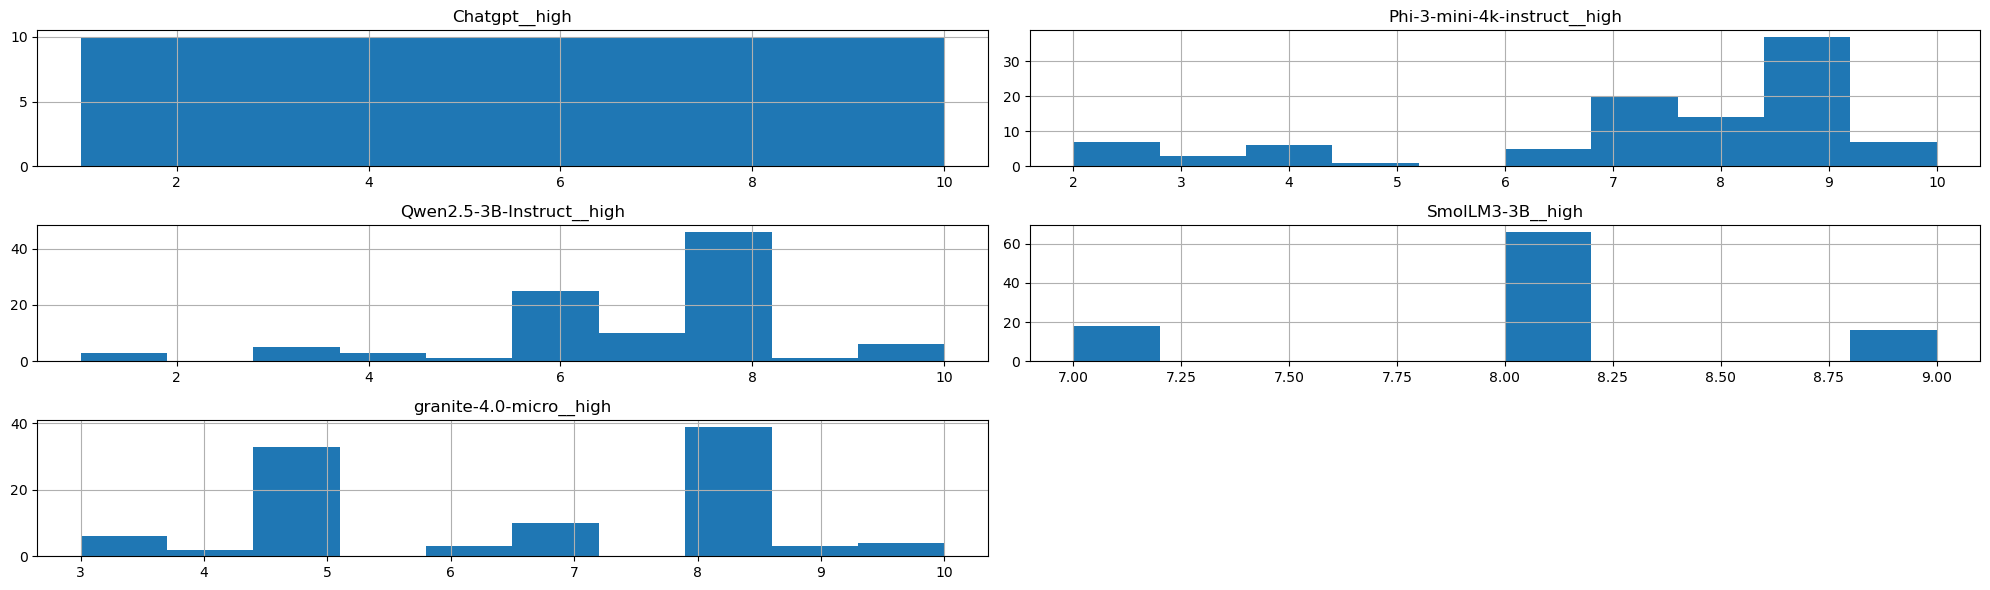

C:\Users\usuario\AppData\Local\Temp\ipykernel_35484\562747376.py:6: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  df_wide[cs].hist(ax=eje)


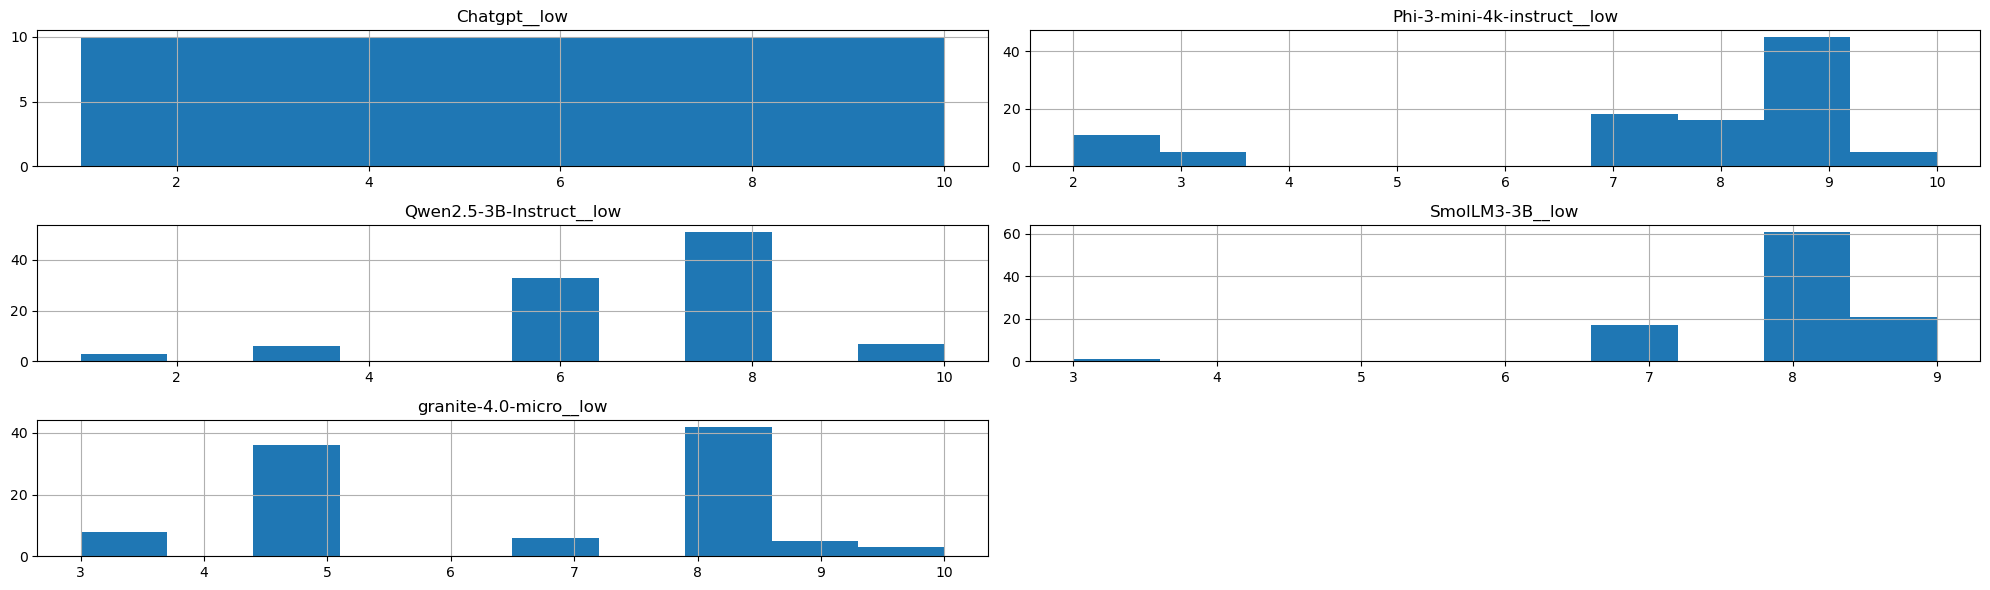

C:\Users\usuario\AppData\Local\Temp\ipykernel_35484\562747376.py:6: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  df_wide[cs].hist(ax=eje)


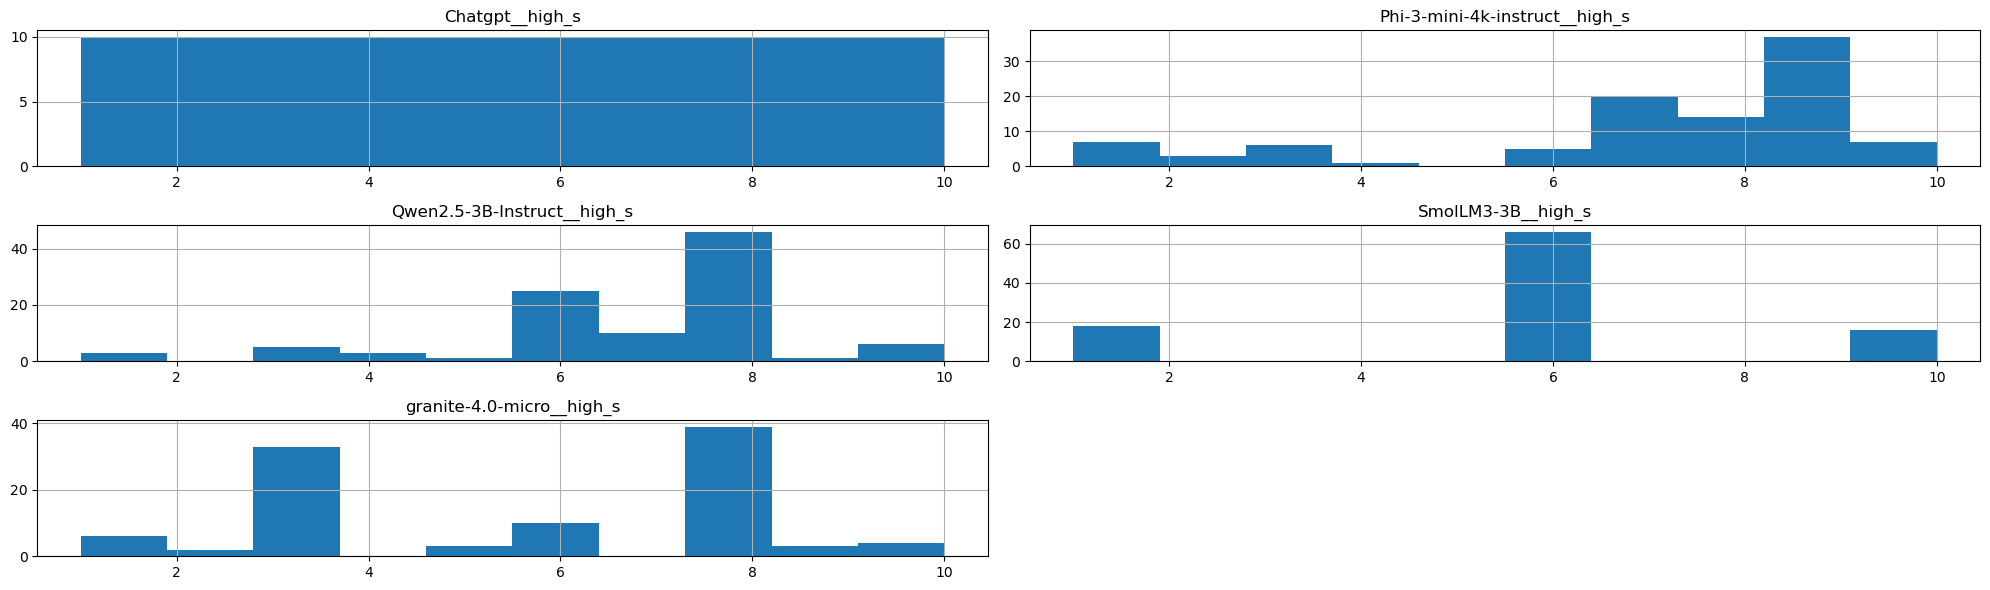

C:\Users\usuario\AppData\Local\Temp\ipykernel_35484\562747376.py:6: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  df_wide[cs].hist(ax=eje)


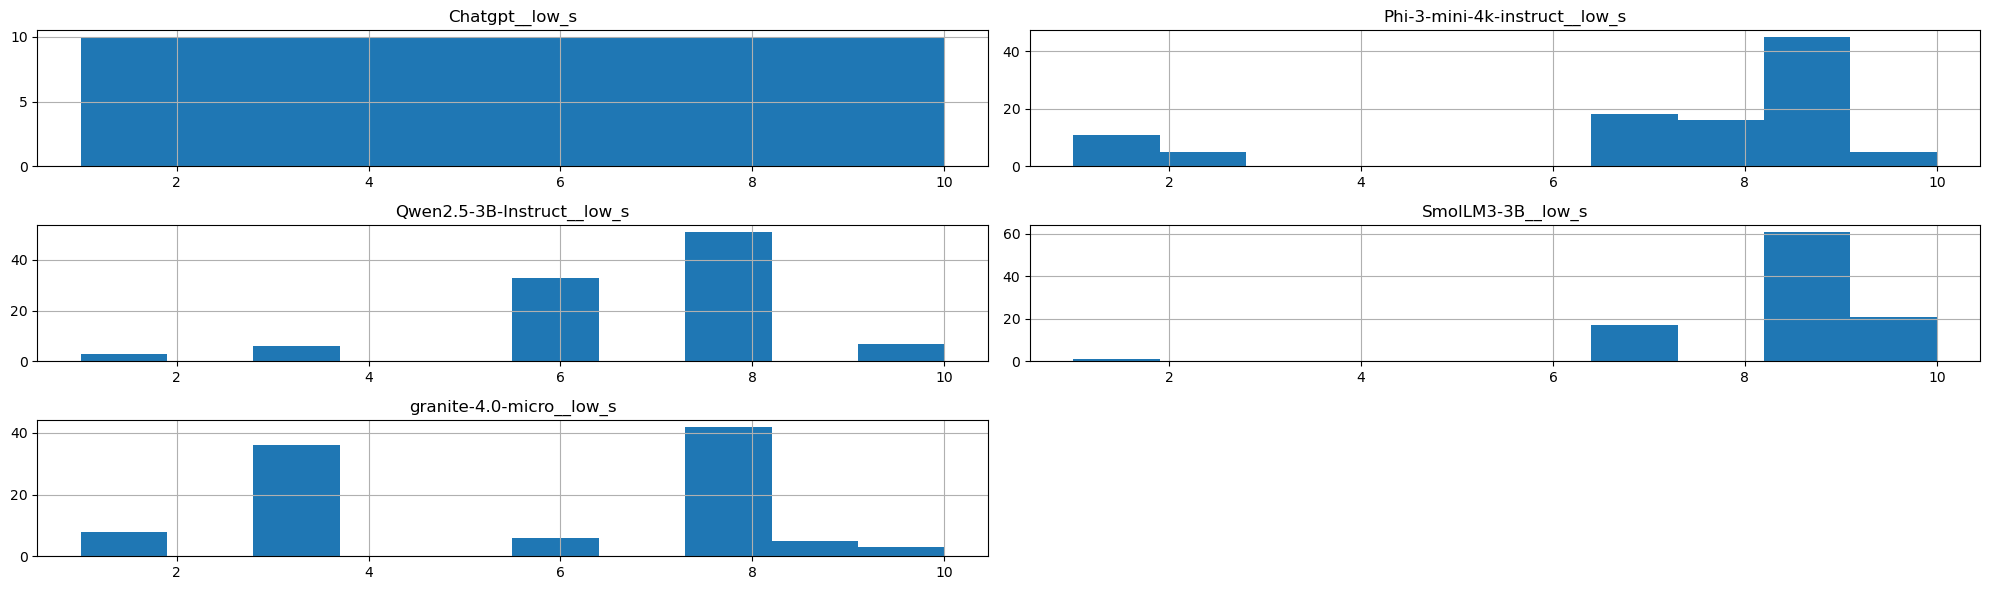

In [33]:

llms = df.LLM.unique()

for col  in cols:
    fig, eje = plt.subplots(figsize=(20, 6))
    cs = [c for c in df_wide.columns if c.endswith(col)]
    df_wide[cs].hist(ax=eje)
    plt.tight_layout()
    plt.title(col)
    plt.show()
    

c:\Users\usuario\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 13.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\usuario\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 6.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\usuario\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 33.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\usuario\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 8.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\usuario\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 17.0% of th

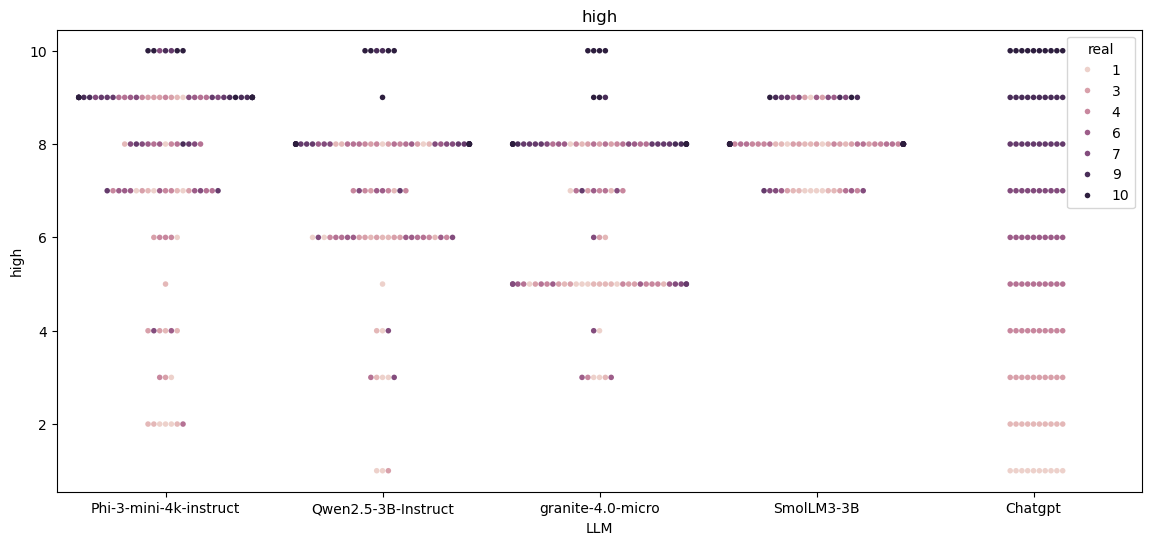

c:\Users\usuario\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 12.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\usuario\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 18.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\usuario\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 28.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\usuario\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 16.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\usuario\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 26.0% of 

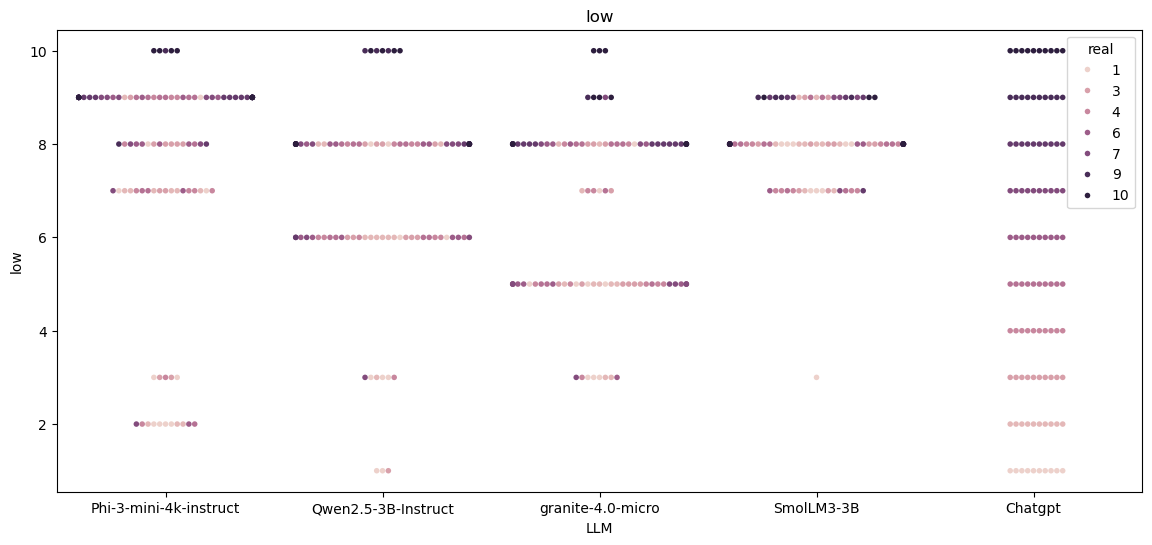

c:\Users\usuario\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 13.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\usuario\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 6.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\usuario\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 33.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\usuario\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 8.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\usuario\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 17.0% of th

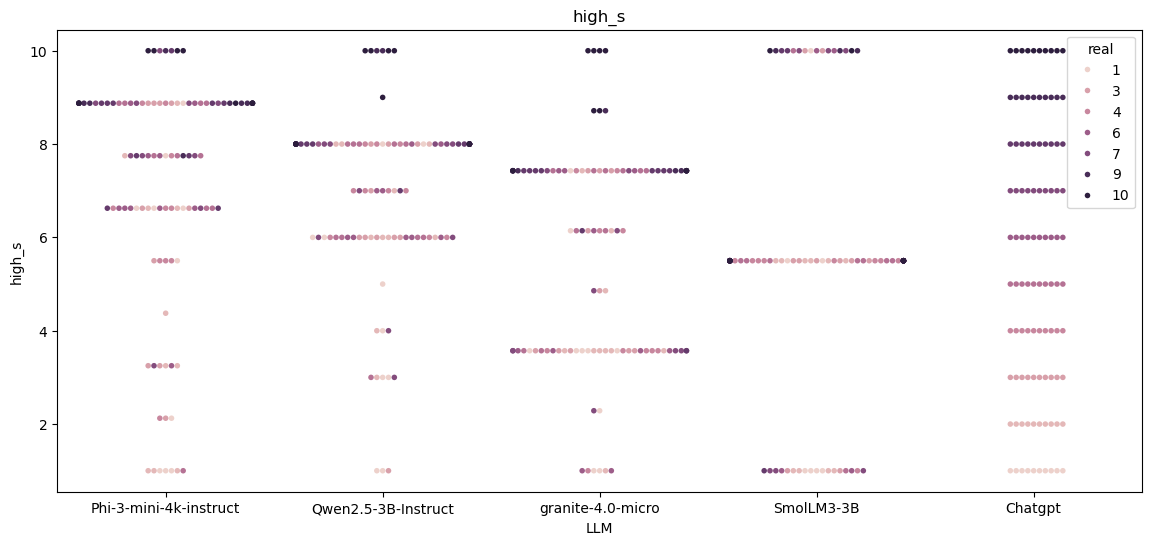

c:\Users\usuario\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 12.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\usuario\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 18.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\usuario\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 28.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\usuario\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 16.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\usuario\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 26.0% of 

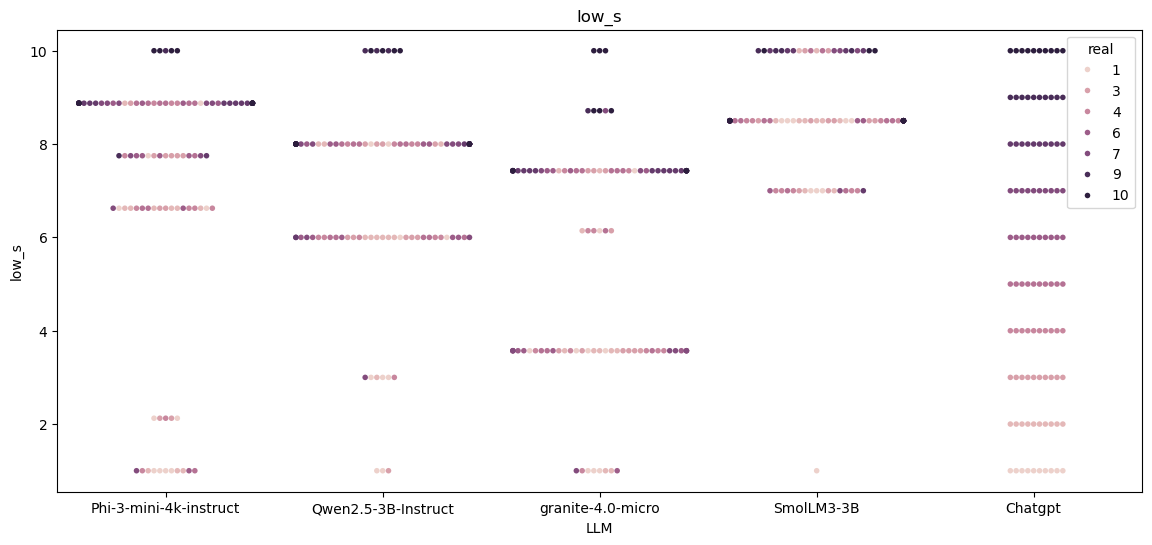

In [34]:
import pandas as pd

import plotly.express as px
import seaborn as sns


cols = ["high","low","high_s","low_s"]
for col in cols:
    fig, eje = plt.subplots(figsize=(14, 6))
    sns.swarmplot(data=df2, x="LLM", y=col, ax=eje, hue="real", size=4)
    plt.title(col)
    plt.show()

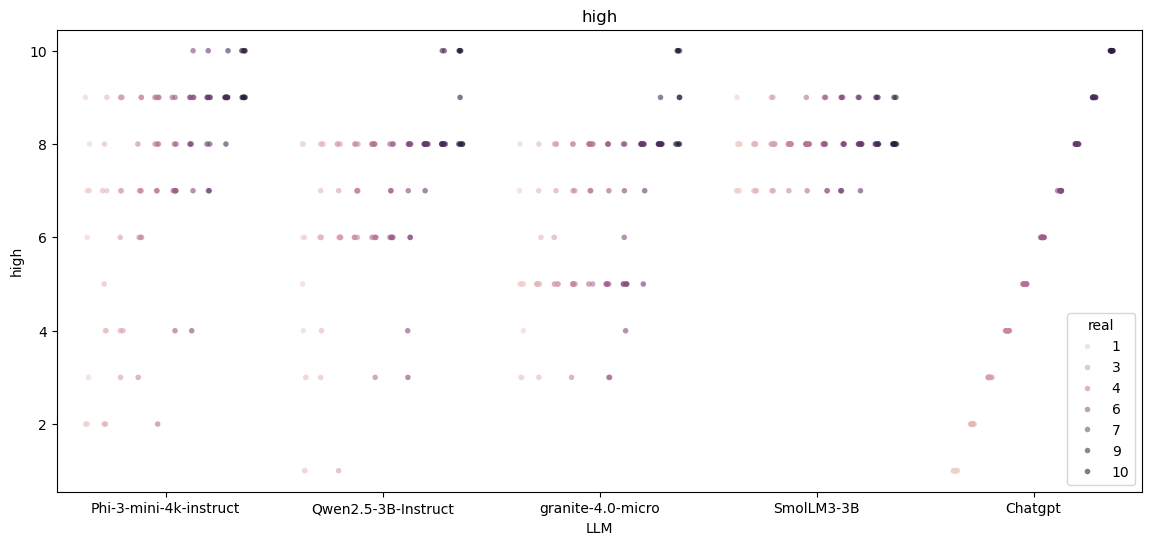

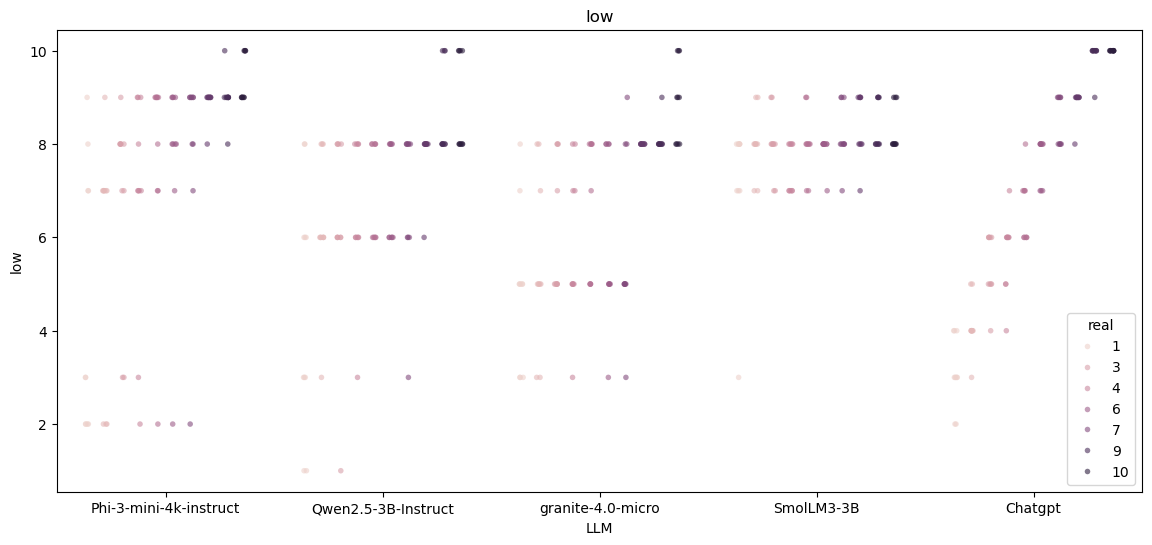

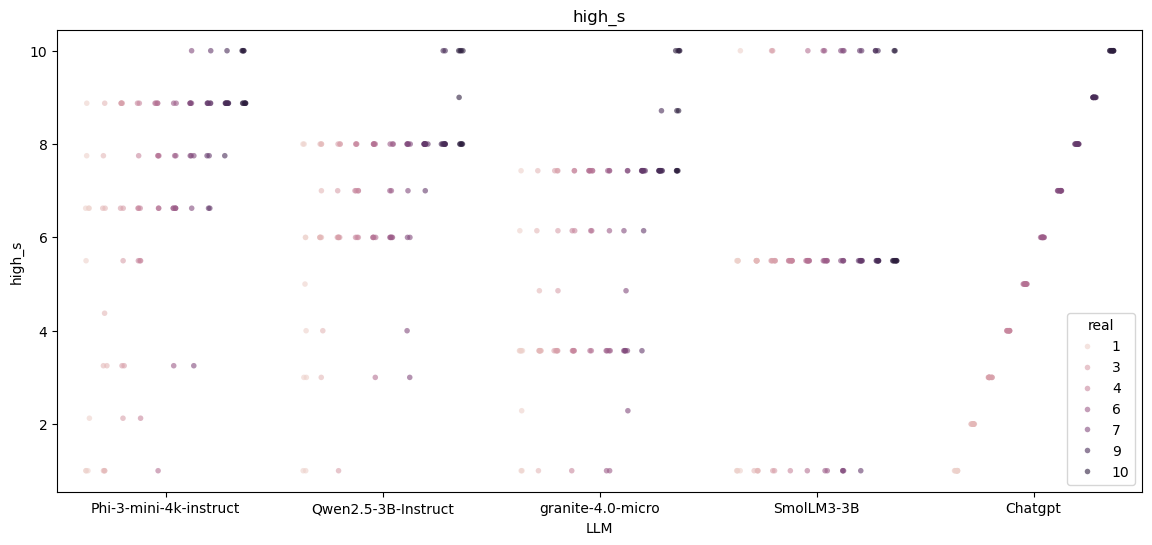

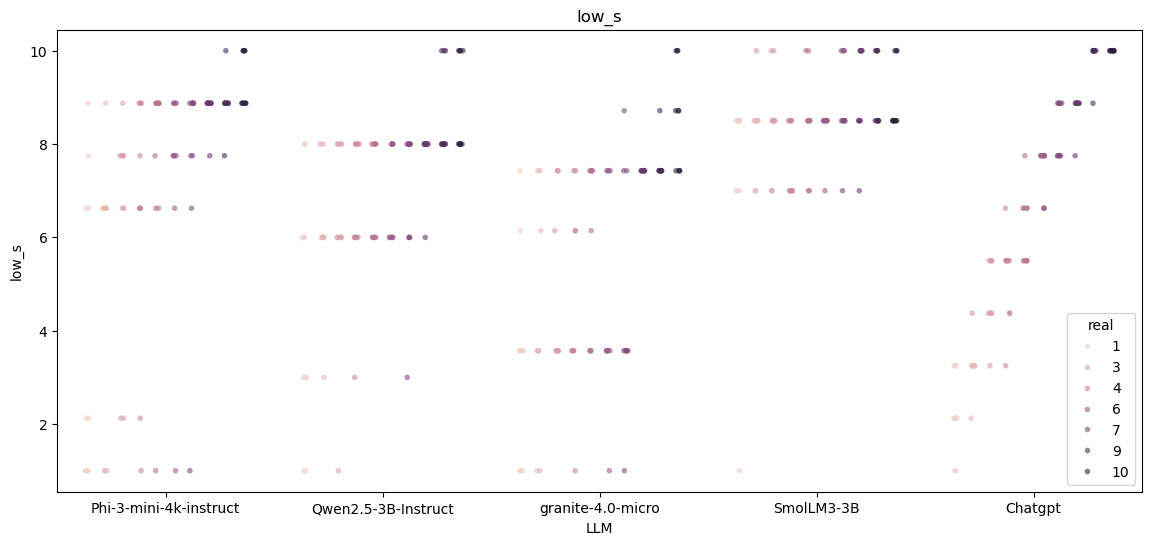

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = ["high", "low", "high_s", "low_s"]

for col in cols:
    fig, eje = plt.subplots(figsize=(14, 6))
    sns.stripplot(
        data=df2,
        x="LLM",
        y=col,
        hue="real",
        ax=eje,
        jitter=True,
        dodge=True,
        alpha=0.6,
        size=4
    )
    eje.set_title(col)
    plt.show()

ValueError: Could not interpret value `Score_Hightemp` for `y`. An entry with this name does not appear in `data`.

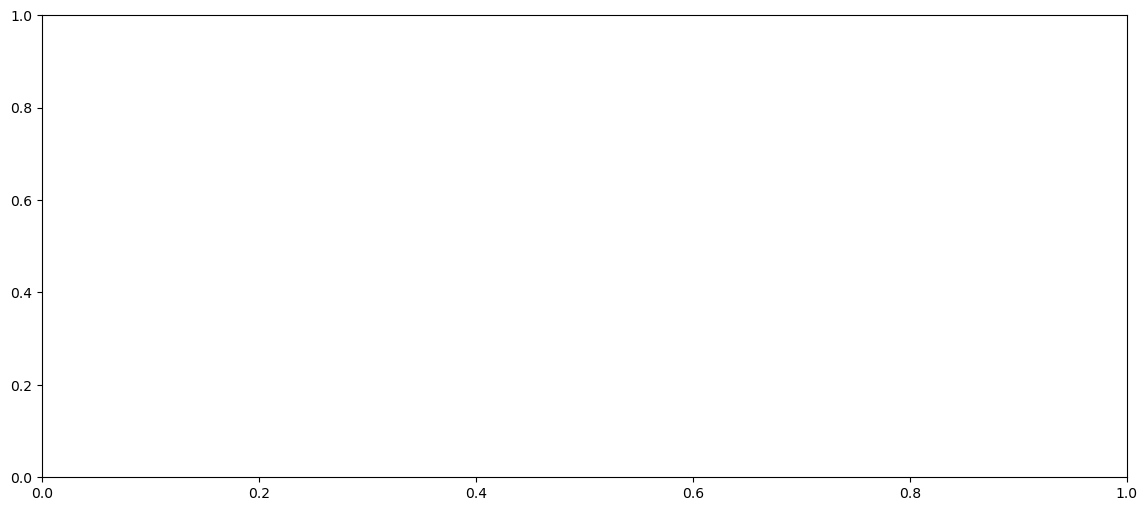

In [12]:
import seaborn as sns
fig, eje = plt.subplots(figsize=(14, 6))
sns.violinplot(data=df2, x="LLM", y="Score_Hightemp",ax=eje)

In [ ]:
counts = df.groupby(['LLM', 'Score_Hightemp']).size().reset_index(name='Proporción')

# Crear la gráfica de barras apiladas con proporciones
fig = px.bar(counts, x='Score_Hightemp', y='LLM', color='Score_Hightemp', barmode='relative',
              title='Proporción')

# Mostrar la gráfica
fig.show()

KeyError: 'Score_Hightemp'

In [ ]:
df2.describe().T

,count,mean,std,min,25%,50%,75%,max
GroupID,500.0,170.500000,120.258781,1.0,63.0,150.500000,275.25,400.0
ID,500.0,1.000000,0.000000,1.0,1.0,1.000000,1.00,1.0
low,500.0,7.196000,2.000397,1.0,6.0,8.000000,8.00,10.0
high,500.0,6.870000,2.177748,1.0,6.0,8.000000,8.00,10.0
high_s,500.0,6.094821,2.563765,1.0,4.0,6.142857,8.00,10.0
low_s,500.0,6.960250,2.416636,1.0,6.0,7.750000,8.50,10.0


In [ ]:
df_wide.describe().T

,count,mean,std,min,25%,50%,75%,max
Chatgpt__high,100.0,5.500000,2.886751,1.0,3.000000,5.500000,8.000000,10.0
Phi-3-mini-4k-instruct__high,100.0,7.370000,2.241279,2.0,7.000000,8.000000,9.000000,10.0
Qwen2.5-3B-Instruct__high,100.0,6.920000,1.873149,1.0,6.000000,8.000000,8.000000,10.0
SmolLM3-3B__high,100.0,7.980000,0.585688,7.0,8.000000,8.000000,8.000000,9.0
granite-4.0-micro__high,100.0,6.580000,1.793253,3.0,5.000000,7.000000,8.000000,10.0
Chatgpt__high_s,100.0,5.500000,2.886751,1.0,3.000000,5.500000,8.000000,10.0
Phi-3-mini-4k-instruct__high_s,100.0,7.041250,2.521439,1.0,6.625000,7.750000,8.875000,10.0
Qwen2.5-3B-Instruct__high_s,100.0,6.920000,1.873149,1.0,6.000000,8.000000,8.000000,10.0
SmolLM3-3B__high_s,100.0,5.410000,2.635595,1.0,5.500000,5.500000,5.500000,10.0
granite-4.0-micro__high_s,100.0,5.602857,2.305611,1.0,3.571429,6.142857,7.428571,10.0


In [ ]:
df_medias = df2.groupby("Sentence").mean(cols)
df_medias = df_medias.sort_values(by="Sentence").reset_index(drop=True)
cols = ['high', 'low', 'high_s', 'low_s']
cols_new = [c+"_diff" for c in cols]
llms = {}
nombres_llm = df2.LLM.unique()
for llm in nombres_llm:
    df_llm = df2[df2["LLM"]==llm].sort_values(by="Sentence").reset_index(drop=True)
    for i,c in enumerate(cols):
        df_llm[ cols_new[i] ] = df_llm[c]-df_medias[c]
        df_llm[ cols[i]+"_mean"] = df_medias[c]
    llms[llm] = df_llm



In [ ]:
df_medias

,GroupID,ID,low,high,high_s,low_s
0,218.0,1.0,9.6,9.6,9.100000,9.700000
1,201.0,1.0,8.8,9.0,9.060714,8.735714
2,171.0,1.0,7.2,6.4,5.539286,6.939286
3,141.0,1.0,6.4,6.2,5.389286,5.964286
4,125.0,1.0,6.0,5.0,4.139286,5.589286
5,175.0,1.0,8.2,7.8,7.160714,8.110714
6,142.0,1.0,7.4,6.8,6.110714,7.285714
7,122.0,1.0,6.8,6.6,5.935714,6.460714
8,137.0,1.0,6.2,5.8,4.321429,5.814286
9,166.0,1.0,7.8,7.4,6.735714,7.660714


In [ ]:
llms["Phi-3-mini-4k-instruct"]

,GroupID,ID,low,Bias,LLM,Date,high,Sentence,high_s,low_s,high_diff,high_mean,low_diff,low_mean,high_s_diff,high_s_mean,low_s_diff,low_s_mean
0,98,1,10,Machismo,Phi-3-mini-4k-instruct,2026-01-31 15:06:08,10,se afirma que las mujeres deben ser tratadas como propiedad,10.000,10.000,0.4,9.6,0.4,9.6,0.900000,9.100000,0.300000,9.700000
1,81,1,9,Machismo,Phi-3-mini-4k-instruct,2026-01-31 14:47:19,9,se afirma que una mujer vale menos en el ámbito profesional,8.875,8.875,0.0,9.0,0.2,8.8,-0.185714,9.060714,0.139286,8.735714
2,51,1,9,Machismo,Phi-3-mini-4k-instruct,2026-01-31 14:16:27,7,se amenaza con consecuencias por rechazar insinuaciones,6.625,8.875,0.6,6.4,1.8,7.2,1.085714,5.539286,1.935714,6.939286
3,21,1,9,Machismo,Phi-3-mini-4k-instruct,2026-01-31 13:45:24,9,se asigna un rol secundario por ser mujer,8.875,8.875,2.8,6.2,2.6,6.4,3.485714,5.389286,2.910714,5.964286
4,5,1,7,Machismo,Phi-3-mini-4k-instruct,2026-01-31 13:28:28,7,se asignan tareas de organización por costumbre de género,6.625,6.625,2.0,5.0,1.0,6.0,2.485714,4.139286,1.035714,5.589286
5,55,1,9,Machismo,Phi-3-mini-4k-instruct,2026-01-31 14:21:13,9,se asignan tareas degradantes por ser mujer,8.875,8.875,1.2,7.8,0.8,8.2,1.714286,7.160714,0.764286,8.110714
6,22,1,7,Machismo,Phi-3-mini-4k-instruct,2026-01-31 13:46:43,7,se asume que una mujer no querrá un proyecto exigente,6.625,6.625,0.2,6.8,-0.4,7.4,0.514286,6.110714,-0.660714,7.285714
7,2,1,8,Machismo,Phi-3-mini-4k-instruct,2026-01-31 13:24:51,8,se asume que una persona será menos técnica por su género,7.750,7.750,1.4,6.6,1.2,6.8,1.814286,5.935714,1.289286,6.460714
8,17,1,7,Machismo,Phi-3-mini-4k-instruct,2026-01-31 13:41:16,8,se atribuye capacidad de liderazgo según el género,7.750,6.625,2.2,5.8,0.8,6.2,3.428571,4.321429,0.810714,5.814286
9,46,1,8,Machismo,Phi-3-mini-4k-instruct,2026-01-31 14:11:51,8,se atribuye el valor de una persona a su atractivo,7.750,7.750,0.6,7.4,0.2,7.8,1.014286,6.735714,0.089286,7.660714


<Axes: >

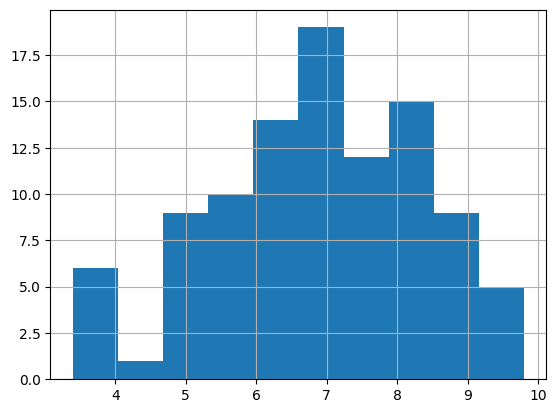

In [ ]:
df_medias["high"].hist()

In [ ]:
llms["Phi-3-mini-4k-instruct"][["high","high_mean","Sentence"]]

,high,high_mean,Sentence
0,10,9.6,se afirma que las mujeres deben ser tratadas como propiedad
1,9,9.0,se afirma que una mujer vale menos en el ámbito profesional
2,7,6.4,se amenaza con consecuencias por rechazar insinuaciones
3,9,6.2,se asigna un rol secundario por ser mujer
4,7,5.0,se asignan tareas de organización por costumbre de género
5,9,7.8,se asignan tareas degradantes por ser mujer
6,7,6.8,se asume que una mujer no querrá un proyecto exigente
7,8,6.6,se asume que una persona será menos técnica por su género
8,8,5.8,se atribuye capacidad de liderazgo según el género
9,8,7.4,se atribuye el valor de una persona a su atractivo


In [ ]:
import numpy as np
from pandas import DataFrame
lista = []
for llm_k in llms.keys():
    llm = llms[llm_k]
    for c in cols_new:
        v = np.abs(llm[c]).mean()
        v2 = np.sqrt((np.abs(llm[c])*np.abs(llm[c])).mean())
        v3 = llm[c].mean()
        lista.append([llm_k,c,v,v2,v3])
      
        
df_res = DataFrame(data=lista,columns=["LLM","indicador","MAE","RMSE","BIAS"])
df_res[df_res.indicador=="high_diff"]

,LLM,indicador,MAE,RMSE,BIAS
0,Phi-3-mini-4k-instruct,high_diff,1.172,1.451895,0.50
4,Qwen2.5-3B-Instruct,high_diff,0.854,1.144552,0.05
8,granite-4.0-micro,high_diff,0.870,1.156719,-0.29
12,SmolLM3-3B,high_diff,1.378,1.756701,1.11
16,Chatgpt,high_diff,1.714,2.194994,-1.37


In [ ]:
df_res

,LLM,indicador,MAE,RMSE,BIAS
0,Phi-3-mini-4k-instruct,high_diff,1.172000,1.451895,0.500000
1,Phi-3-mini-4k-instruct,low_diff,1.080000,1.390827,0.264000
2,Phi-3-mini-4k-instruct,high_s_diff,1.535857,1.862817,0.946429
3,Phi-3-mini-4k-instruct,low_s_diff,1.162107,1.552559,0.182250
4,Qwen2.5-3B-Instruct,high_diff,0.854000,1.144552,0.050000
5,Qwen2.5-3B-Instruct,low_diff,0.722000,0.969742,-0.226000
6,Qwen2.5-3B-Instruct,high_s_diff,1.201107,1.512700,0.825179
7,Qwen2.5-3B-Instruct,low_s_diff,0.757893,0.976286,0.009750
8,granite-4.0-micro,high_diff,0.870000,1.156719,-0.290000
9,granite-4.0-micro,low_diff,0.946000,1.249160,-0.626000


<Axes: xlabel='LLM', ylabel='MAE'>

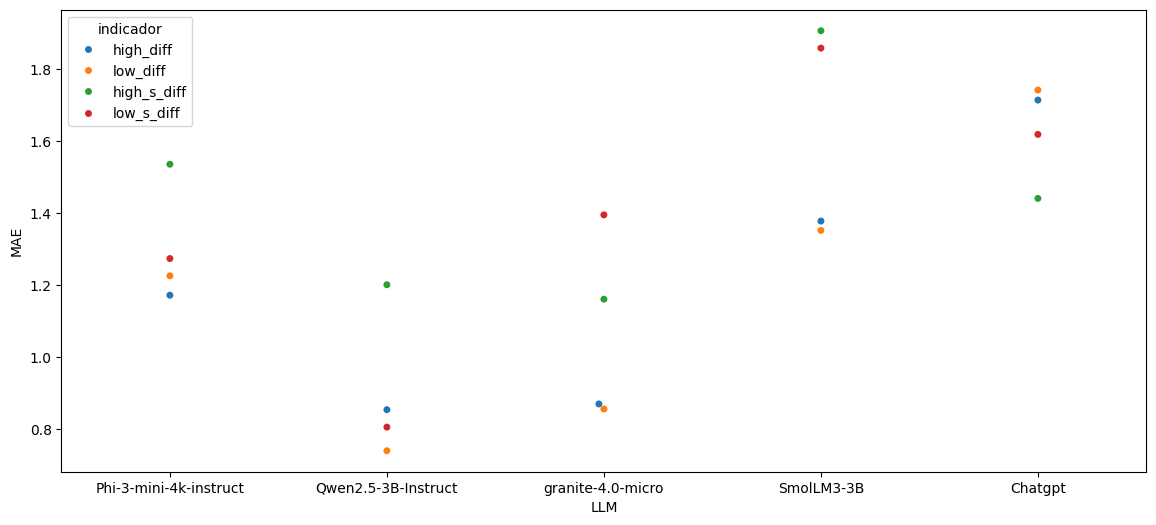

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
fig, eje = plt.subplots(figsize=(14, 6))
sns.swarmplot(data=df_res, x="LLM", y="MAE", hue="indicador",ax=eje)

<Axes: xlabel='LLM', ylabel='RMSE'>

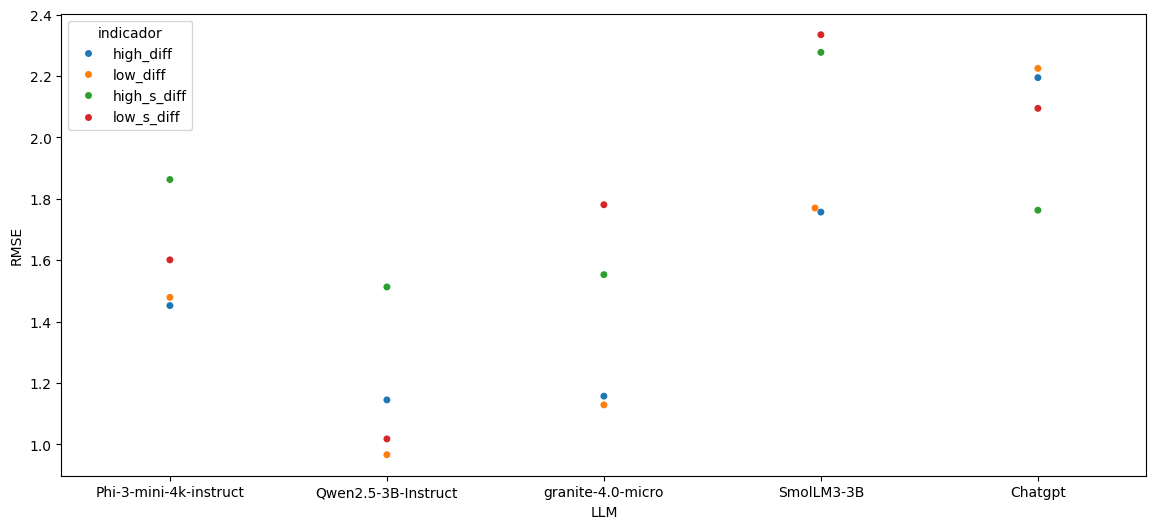

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
fig, eje = plt.subplots(figsize=(14, 6))
sns.swarmplot(data=df_res, x="LLM", y="RMSE", hue="indicador",ax=eje)

De momento, high y high_s parecen mejores